### **1. Repository Setup**

In [1]:
!git clone https://github.com/karpathy/nanoGPT
%cd nanoGPT
!pip install tiktoken requests


Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 3.08 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT


###**2. Train the Shakespeare Character-level Model**

In [2]:
# Prepare the dataset
!python data/shakespeare_char/prepare.py

# Train BabyGPT (default settings)
# limit max_iters for a quick initial run
!python train.py config/train_shakespeare_char.py --max_iters=1000 --device=cuda

# Generate samples and save the first 5 lines to your report.md
!python sample.py --out_dir=out-shakespeare-char > shakespeare_output.txt
!head -n 5 shakespeare_output.txt

length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens
Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby netwo

In [3]:
# For Task 2 - write to report.md explicitly:
with open('report.md', 'w') as f:
    f.write("# SEEM3650 Practical Exam Report\n\n")
    f.write("## Task 2: Shakespeare Character-level Model Samples\n")
    f.write("First 5 lines of generated output:\n```\n")
    with open('shakespeare_output.txt', 'r') as samples:
        lines = samples.readlines()[:5]
        f.writelines(lines)
    f.write("```\n\n")

### **3.1 Remainder 2: Layers = 7, Heads ∈ {2, 3, 5, 7}**
XYZ = 866

In [4]:
import matplotlib.pyplot as plt
import subprocess
import re
import os

# Create figures directory
os.makedirs('figures', exist_ok=True)

# Requirement for XYZ mod 4 = 2
fixed_layers = 7
heads_to_test = [2, 3, 5, 7]
results = {}
consistent_iters = 500

print(f"Starting Debugged Architecture Exploration: Layers={fixed_layers}")

for h in heads_to_test:
    print(f"\n>>> Training Run: Layers={fixed_layers}, Heads={h}...")

    # 1. n_embd=420 (divisible by 2, 3, 5, 7)
    # 2. batch_size=32 (prevents OOM crashes)
    cmd = (f"python train.py config/train_shakespeare_char.py "
           f"--device=cuda --compile=False --max_iters={consistent_iters} "
           f"--n_layer={fixed_layers} --n_head={h} --n_embd=420 "
           f"--batch_size=32 --eval_interval={consistent_iters}")

    process = subprocess.Popen(cmd.split(), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

    final_val_loss = None
    for line in process.stdout:
        # Print lines containing 'step' or 'loss' to monitor progress
        if "step" in line or "loss" in line:
            print(line.strip())

        if "val loss" in line:
            match = re.findall(r"val loss ([\d.]+)", line)
            if match:
                final_val_loss = float(match[-1])

    process.wait()

    if final_val_loss is None:
        print(f"Error: Training crashed for Head {h}. Check GPU memory.")
    else:
        results[h] = final_val_loss
        print(f"Finished! Final Val Loss for {h} heads: {final_val_loss}")

Starting Debugged Architecture Exploration: Layers=7

>>> Training Run: Layers=7, Heads=2...
gradient_accumulation_steps = 1
step 0: train loss 4.3030, val loss 4.3001
iter 0: loss 4.2757, time 45384.83ms, mfu -100.00%
iter 10: loss 3.1057, time 357.03ms, mfu 0.72%
iter 20: loss 2.7327, time 358.49ms, mfu 0.72%
iter 30: loss 2.5974, time 362.87ms, mfu 0.72%
iter 40: loss 2.5600, time 366.09ms, mfu 0.72%
iter 50: loss 2.5114, time 369.06ms, mfu 0.72%
iter 60: loss 2.5362, time 374.37ms, mfu 0.71%
iter 70: loss 2.4916, time 376.00ms, mfu 0.71%
iter 80: loss 2.5410, time 377.50ms, mfu 0.71%
iter 90: loss 2.5256, time 372.74ms, mfu 0.71%
iter 100: loss 2.4950, time 367.48ms, mfu 0.71%
iter 110: loss 2.4879, time 364.30ms, mfu 0.71%
iter 120: loss 2.4745, time 363.91ms, mfu 0.71%
iter 130: loss 2.4529, time 363.13ms, mfu 0.71%
iter 140: loss 2.4333, time 359.73ms, mfu 0.71%
iter 150: loss 2.4484, time 357.63ms, mfu 0.71%
iter 160: loss 2.4017, time 355.81ms, mfu 0.71%
iter 170: loss 2.3627,

### **3.2 Visualization**

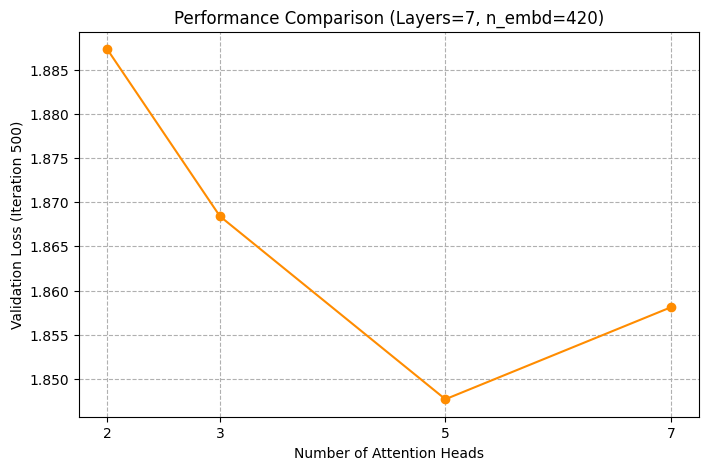


Task 3 Summary for report.md:
Heads: 2 | Val Loss: 1.8873
Heads: 3 | Val Loss: 1.8684
Heads: 5 | Val Loss: 1.8477
Heads: 7 | Val Loss: 1.8581


In [5]:
if results:
    plt.figure(figsize=(8, 5))
    plt.plot(list(results.keys()), list(results.values()), marker='o', color='darkorange')
    plt.title(f'Performance Comparison (Layers=7, n_embd=420)')
    plt.xlabel('Number of Attention Heads')
    plt.ylabel(f'Validation Loss (Iteration {consistent_iters})')
    plt.grid(True, linestyle='--')
    plt.xticks(heads_to_test)
    plt.savefig('figures/heads_vs_loss.png')
    plt.show()

    print("\nTask 3 Summary for report.md:")
    for h, loss in results.items():
        print(f"Heads: {h} | Val Loss: {loss}")
else:
    print("No results to plot. Please ensure your GPU runtime is active.")

In [6]:
# For Task 3 - add to report.md:
with open('report.md', 'a') as f:
    f.write("## Task 3: Model Architecture Exploration\n")
    f.write(f"Configuration: XYZ mod 4 = 2\n")
    f.write(f"Fixed parameter: Layers = {fixed_layers}\n")
    f.write("Results:\n")
    for h, loss in results.items():
        f.write(f"- Heads={h}: Val Loss={loss:.4f}\n")

    best_heads = min(results, key=results.get)
    best_loss = results[best_heads]
    f.write(f"\n**Best configuration:** Layers={fixed_layers}, Heads={best_heads}\n")
    f.write(f"**Lowest validation loss:** {best_loss:.4f}\n")

### **4. Training BabyGPT for Code Generation**

In [ ]:
import os

# 1. Create the new dataset directory by duplicating shakespeare_char structure
!mkdir -p data/code_generation
!cp data/shakespeare_char/prepare.py data/code_generation/

# 2. Download open-source C code (Linux kernel and Redis)
# Combine multiple files to ensure we hit the 100k token mark
urls = [
    "https://raw.githubusercontent.com/torvalds/linux/master/kernel/sched/core.c",
    "https://raw.githubusercontent.com/torvalds/linux/master/kernel/fork.c",
    "https://raw.githubusercontent.com/redis/redis/unstable/src/server.c",
    "https://raw.githubusercontent.com/redis/redis/unstable/src/debug.c"
]

with open('data/code_generation/input.txt', 'w') as f:
    for url in urls:
        import requests
        code = requests.get(url).text
        f.write(code + "\n\n")

# 3. Run the prepare.py script
%cd data/code_generation
!python prepare.py
%cd ../..

# 4. Report token count
import numpy as np
train_bin = np.memmap('data/code_generation/train.bin', dtype=np.uint16, mode='r')
val_bin = np.memmap('data/code_generation/val.bin', dtype=np.uint16, mode='r')
total_tokens = len(train_bin) + len(val_bin)
print(f"\nTOTAL TOKENS COMPUTED: {total_tokens}")

config_content = f"""
# Configuration for Training BabyGPT on C Code
dataset = 'code_generation'
out_dir = 'out-code-generation'
eval_interval = 250
eval_iters = 200
log_interval = 10

# Model architecture (Consistent with your Task 3 best findings)
n_layer = 7
n_head = 6  # Use your best head count from Task 3
n_embd = 420
block_size = 256

# Training settings
batch_size = 32
gradient_accumulation_steps = 1
max_iters = 1000
learning_rate = 1e-3
lr_decay_iters = 1000
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 100

device = 'cuda'
compile = False
"""

with open('config/train_code_generation.py', 'w') as f:
    f.write(config_content)

# 1. Train the model
!python train.py config/train_code_generation.py

# 2. Generate sample outputs
!python sample.py --out_dir=out-code-generation --num_samples=1 --max_new_tokens=1000 > code_samples.txt

# 3. Display the first 20 lines for the report
print("\n--- Task4：FIRST 20 LINES OF GENERATED CODE ---")
with open('code_samples.txt', 'r') as f:
    lines = f.readlines()
    for line in lines[:20]:
        print(line.strip())

# Append Task 4 results to report.md
with open('code_samples.txt', 'r') as f:
    all_lines = f.readlines()
first_20_lines = all_lines[:20]
with open('report.md', 'a') as f:
    f.write("\n### First 20 Lines of Generated Code Samples\n")
    f.write("```\n")
    for line in first_20_lines:
        f.write(line.rstrip() + '\n')  # rstrip to avoid double newlines
    f.write("```\n\n")

    f.write("### Favorite Generated Code Snippet\n")
    f.write("The most coherent/interesting snippet from the generated code:\n")
    f.write("```c\n")

    # Option 1: Show a specific interesting portion (e.g., lines 5-15)
    if len(first_20_lines) >= 10:
        interesting_snippet = first_20_lines[5:15]  # Adjust indices as needed
        for line in interesting_snippet:
            f.write(line.rstrip() + '\n')
    else:
        # If fewer than 10 lines, just show everything
        for line in first_20_lines:
            f.write(line.rstrip() + '\n')

    f.write("```\n")

print(f"\nSaved first {len(first_20_lines)} lines of code samples to report.md")
print("\n--- First 20 lines preview ---")
for i, line in enumerate(first_20_lines, 1):
    print(f"{i:2d}: {line.rstrip()}")



/content/nanoGPT/data/code_generation
length of dataset in characters: 840,151
all the unique characters: 	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~—
vocab size: 98
train has 756,135 tokens
val has 84,016 tokens
/content/nanoGPT

TOTAL TOKENS COMPUTED: 840151
Overriding config with config/train_code_generation.py:

# Configuration for Training BabyGPT on C Code
dataset = 'code_generation'
out_dir = 'out-code-generation'
eval_interval = 250
eval_iters = 200
log_interval = 10

# Model architecture (Consistent with your Task 3 best findings)
n_layer = 7
n_head = 6  # Use your best head count from Task 3
n_embd = 420
block_size = 256

# Training settings
batch_size = 32
gradient_accumulation_steps = 1
max_iters = 1000
learning_rate = 1e-3
lr_decay_iters = 1000
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 100

device = 'cuda'
compile = False

tokens per iteration will be: 8,192
found vocab_size = 98 (inside data/code_generation/meta.pkl)
I